# Import Libraries

In [1]:
import os
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data loading, inspection and wrangling

## Visually inspecting the files that were provided, the tables for each month contain roughly the same columns. As such, it is reasonable to assume that the tables are homogeneous.

In [2]:
# Create a function to extract the zip file and read the csv files
def extract_and_read(zip_file_path, data_folder):
    
    # Extract the zip file
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall()

    # create an empty dataframe to store all the csv files
    df = pd.DataFrame()

    # Iterate over the directories in the "data" folder
    for root, dirs, files in os.walk(data_folder):
        for dir in dirs:
            dir_path = os.path.join(root, dir)
            
            # Iterate over the CSV files in each directory
            for file in os.listdir(dir_path):
                if file.endswith(".csv"):
                    file_path = os.path.join(dir_path, file)
                    
                    # Read the CSV file as a dataframe and update the content of df
                    frame = pd.read_csv(file_path)
                    df = pd.concat([df, frame], ignore_index=True)
    
    return df

In [3]:
df = extract_and_read("crime_data.zip", "data")
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158898 entries, 0 to 158897
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             158898 non-null  int64  
 1   Crime ID               129209 non-null  object 
 2   Month                  156898 non-null  object 
 3   Reported by            135113 non-null  object 
 4   Falls within           127620 non-null  object 
 5   Longitude              153411 non-null  float64
 6   Latitude               153411 non-null  float64
 7   Location               156898 non-null  object 
 8   LSOA code              153410 non-null  object 
 9   LSOA name              153410 non-null  object 
 10  Crime type             156898 non-null  object 
 11  Last outcome category  127564 non-null  object 
 12  Context                0 non-null       float64
dtypes: float64(3), int64(1), object(9)
memory usage: 15.8+ MB
None


,Unnamed: 0,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,Context
0,0,9cfc0ed854bc20e2402d91de03c01bb0eec53ca7d1e52f...,2020-06,West Yorkshire Police,West Yorkshire Police,-1.764583,53.534617,On or near Park/Open Space,E01007426,Barnsley 027D,Burglary,Status update unavailable,NaN
1,1,e8ef06134d7cbd661b44b14b0090f533d767b1c56702fc...,2020-06,West Yorkshire Police,West Yorkshire Police,-1.764583,53.534617,On or near Park/Open Space,E01007426,Barnsley 027D,Burglary,Investigation complete; no suspect identified,NaN
2,2,NaN,2020-06,West Yorkshire Police,West Yorkshire Police,-1.873004,53.941724,On or near Cornerstones Close,E01010646,Bradford 001A,Anti-social behaviour,NaN,NaN
3,3,NaN,2020-06,West Yorkshire Police,West Yorkshire Police,-1.882481,53.924936,On or near Moorside Lane,E01010646,Bradford 001A,Anti-social behaviour,NaN,NaN
4,4,NaN,2020-06,West Yorkshire Police,West Yorkshire Police,-1.873004,53.941724,On or near Cornerstones Close,E01010646,Bradford 001A,Anti-social behaviour,NaN,NaN


## The 'Unnamed: 0' column is not useful as it contains just serial numbers. The 'Context' column is also completely empty. Let's drop them.

## The 'Reported by' and 'Falls within' columns seem to contain the same data and the information at https://data.police.uk/about/ confirms this. We can drop the 'Falls within column because it contains more null values compared to the 'Reported by' column.

## Further, the datatype for the 'Month' column is object rather than datetime. Let's cast it to datetime as this will be important for any time-series plots we might want to create.

In [4]:
# Drop the unnamed and context columns since they are not useful to the table
df = df.drop(columns=['Unnamed: 0', 'Context', 'Reported by'])

# Cast the month column to datetime
df['Month'] = pd.to_datetime(df['Month'], format="%Y-%m", dayfirst=True)

## The 'Crime type' column is the most important to the research question. Let's explore it in further details

In [5]:
df['Crime type'].value_counts(normalize=True, dropna=False) * 100

Violence and sexual offences    36.176037
Anti-social behaviour           18.448313
Public order                    11.272011
Criminal damage and arson        8.215333
Other theft                      5.235434
Burglary                         4.434291
Vehicle crime                    4.054173
Shoplifting                      2.993744
Drugs                            2.865360
Other crime                      2.339866
NaN                              1.258669
Robbery                          0.740097
Possession of weapons            0.697932
Bicycle theft                    0.648844
Theft from the person            0.545004
Exclusive                        0.074891
Name: Crime type, dtype: float64

## Just about 1.25% of the entire rows contain null values for the 'Crime type' column. This proportion would not significantly affect the analysis if these rows were dropped.

In [6]:
# Drop null values in the 'Crime type' column
df = df.dropna(subset='Crime type')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 156898 entries, 0 to 158897
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Crime ID               127564 non-null  object        
 1   Month                  156898 non-null  datetime64[ns]
 2   Falls within           127620 non-null  object        
 3   Longitude              153411 non-null  float64       
 4   Latitude               153411 non-null  float64       
 5   Location               156898 non-null  object        
 6   LSOA code              153410 non-null  object        
 7   LSOA name              153410 non-null  object        
 8   Crime type             156898 non-null  object        
 9   Last outcome category  127564 non-null  object        
dtypes: datetime64[ns](1), float64(2), object(7)
memory usage: 13.2+ MB


## Although there are still columns with null values in the dataframe, the most important to the analysis are the 'Month' and 'Crime type' columns which do not contain any null values at this point.

## Finally, let's check for duplicates

In [8]:
df[df.duplicated(keep=False)].info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 13150 entries, 2 to 158537
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Crime ID               0 non-null      object        
 1   Month                  13150 non-null  datetime64[ns]
 2   Falls within           10416 non-null  object        
 3   Longitude              12847 non-null  float64       
 4   Latitude               12847 non-null  float64       
 5   Location               13150 non-null  object        
 6   LSOA code              12847 non-null  object        
 7   LSOA name              12847 non-null  object        
 8   Crime type             13150 non-null  object        
 9   Last outcome category  0 non-null      object        
dtypes: datetime64[ns](1), float64(2), object(7)
memory usage: 1.1+ MB


## All duplicates clearly have no Crime ID. As such, it is difficult to say if these are actually duplicates. For example, if the same crime involves more than one person in the same location and provided that each row is unique to each individual, then without the Crime ID, it is difficult to say that rows containing the same information are duplicates.

## Ideally, clarification should be sought from the police department concerning these rows.

# Exploratory Data Analysis

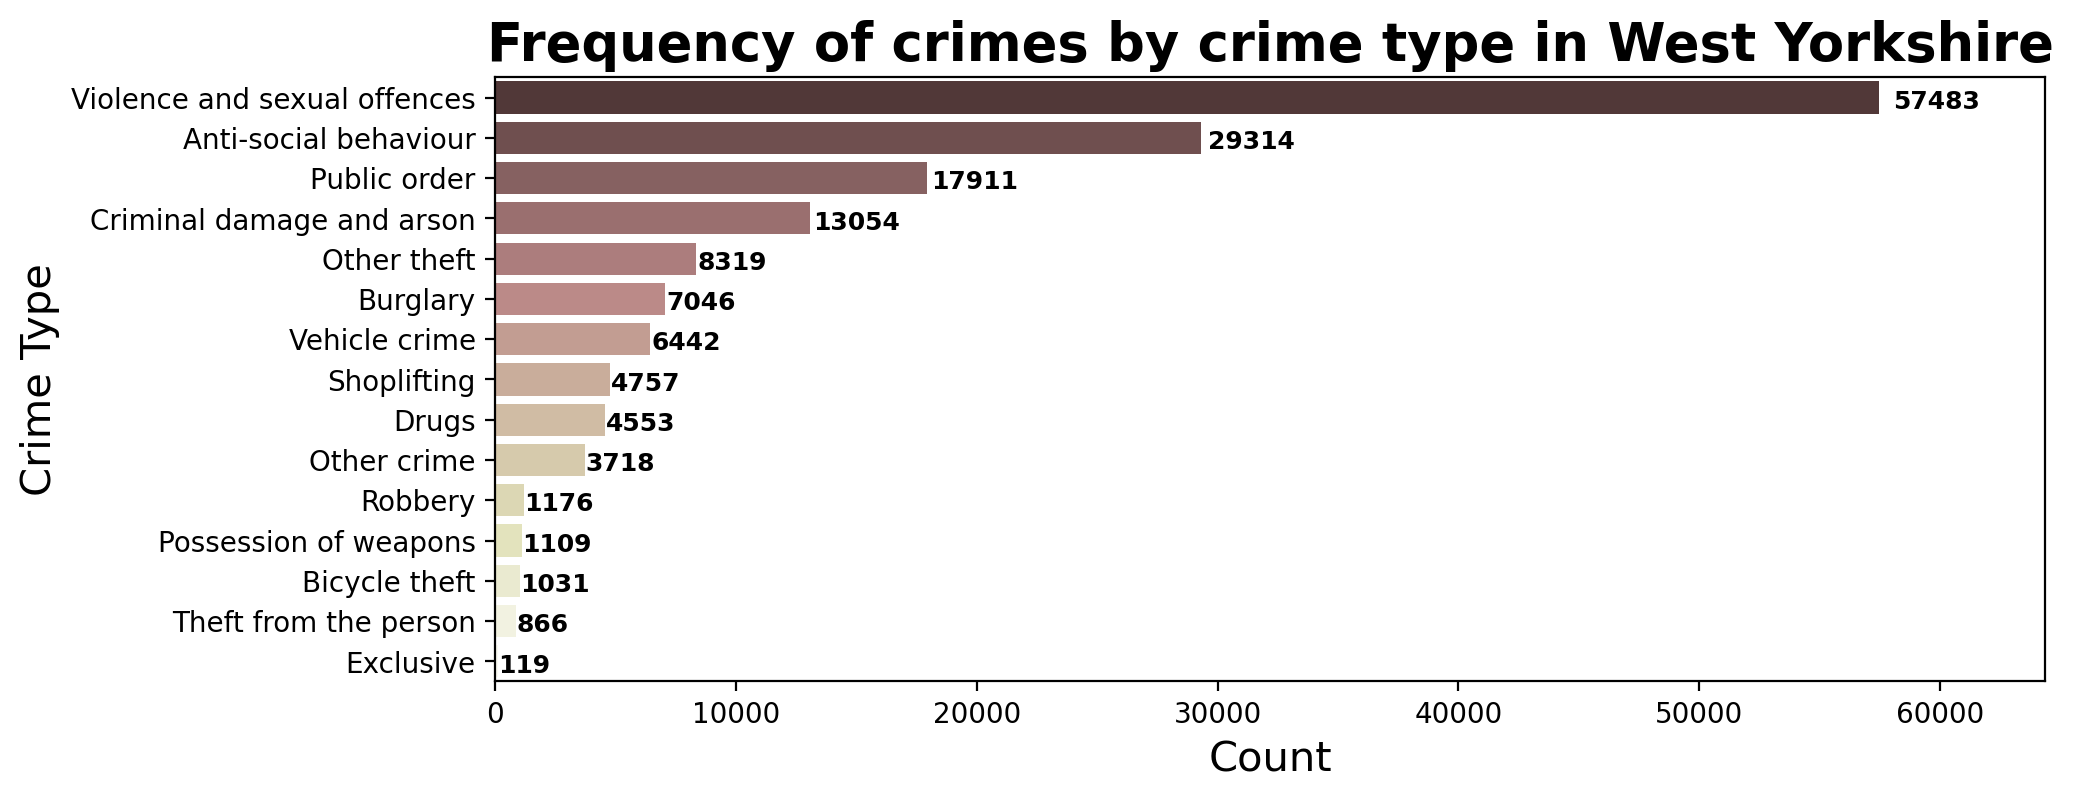

In [9]:
# Create figure canvas
plt.figure(figsize=(10,4), dpi=200)

# Set custom_palette
custom_palette = sns.color_palette("pink", len(df['Crime type'].unique()))

# Create countplot
ax = sns.countplot(data=df, y='Crime type', order=df['Crime type'].value_counts().index, palette=custom_palette)

# Display the count value of each bar beside it
for p in ax.patches:
    ax.annotate(f"{p.get_width()}", (p.get_width()+(0.01*p.get_width()), p.get_y()+0.5), 
                va='center', fontsize=9, fontweight='bold')

# Dynamically change the x_limit to accomodate any count if the dataset changes
max_count = df['Crime type'].value_counts().max()
plt.xlim((0,max_count + (0.12 * max_count)))

# Label appropriately
plt.title('Frequency of crimes by crime type in West Yorkshire', fontsize=19, fontweight='bold')
plt.ylabel('Crime Type', fontsize=15)
plt.xlabel('Count', fontsize=15)
plt.show()

### Crimes related to violence and sexual offences, anti-social behaviour, public order, and criminal damage and arson are the most predominant in West Yorkshire while crimes related to stealing (either through violence or theft) are relatively less prevalent.
### The authorities should look into targeted policing, public awareness and education, as well as rehabilitation and support services to try and reduce crime rate in the city.

## To answer the question, how did counts of the different types of crime change over the 6 month period, heatmap pivot tables and time-series plots can be very insightful.

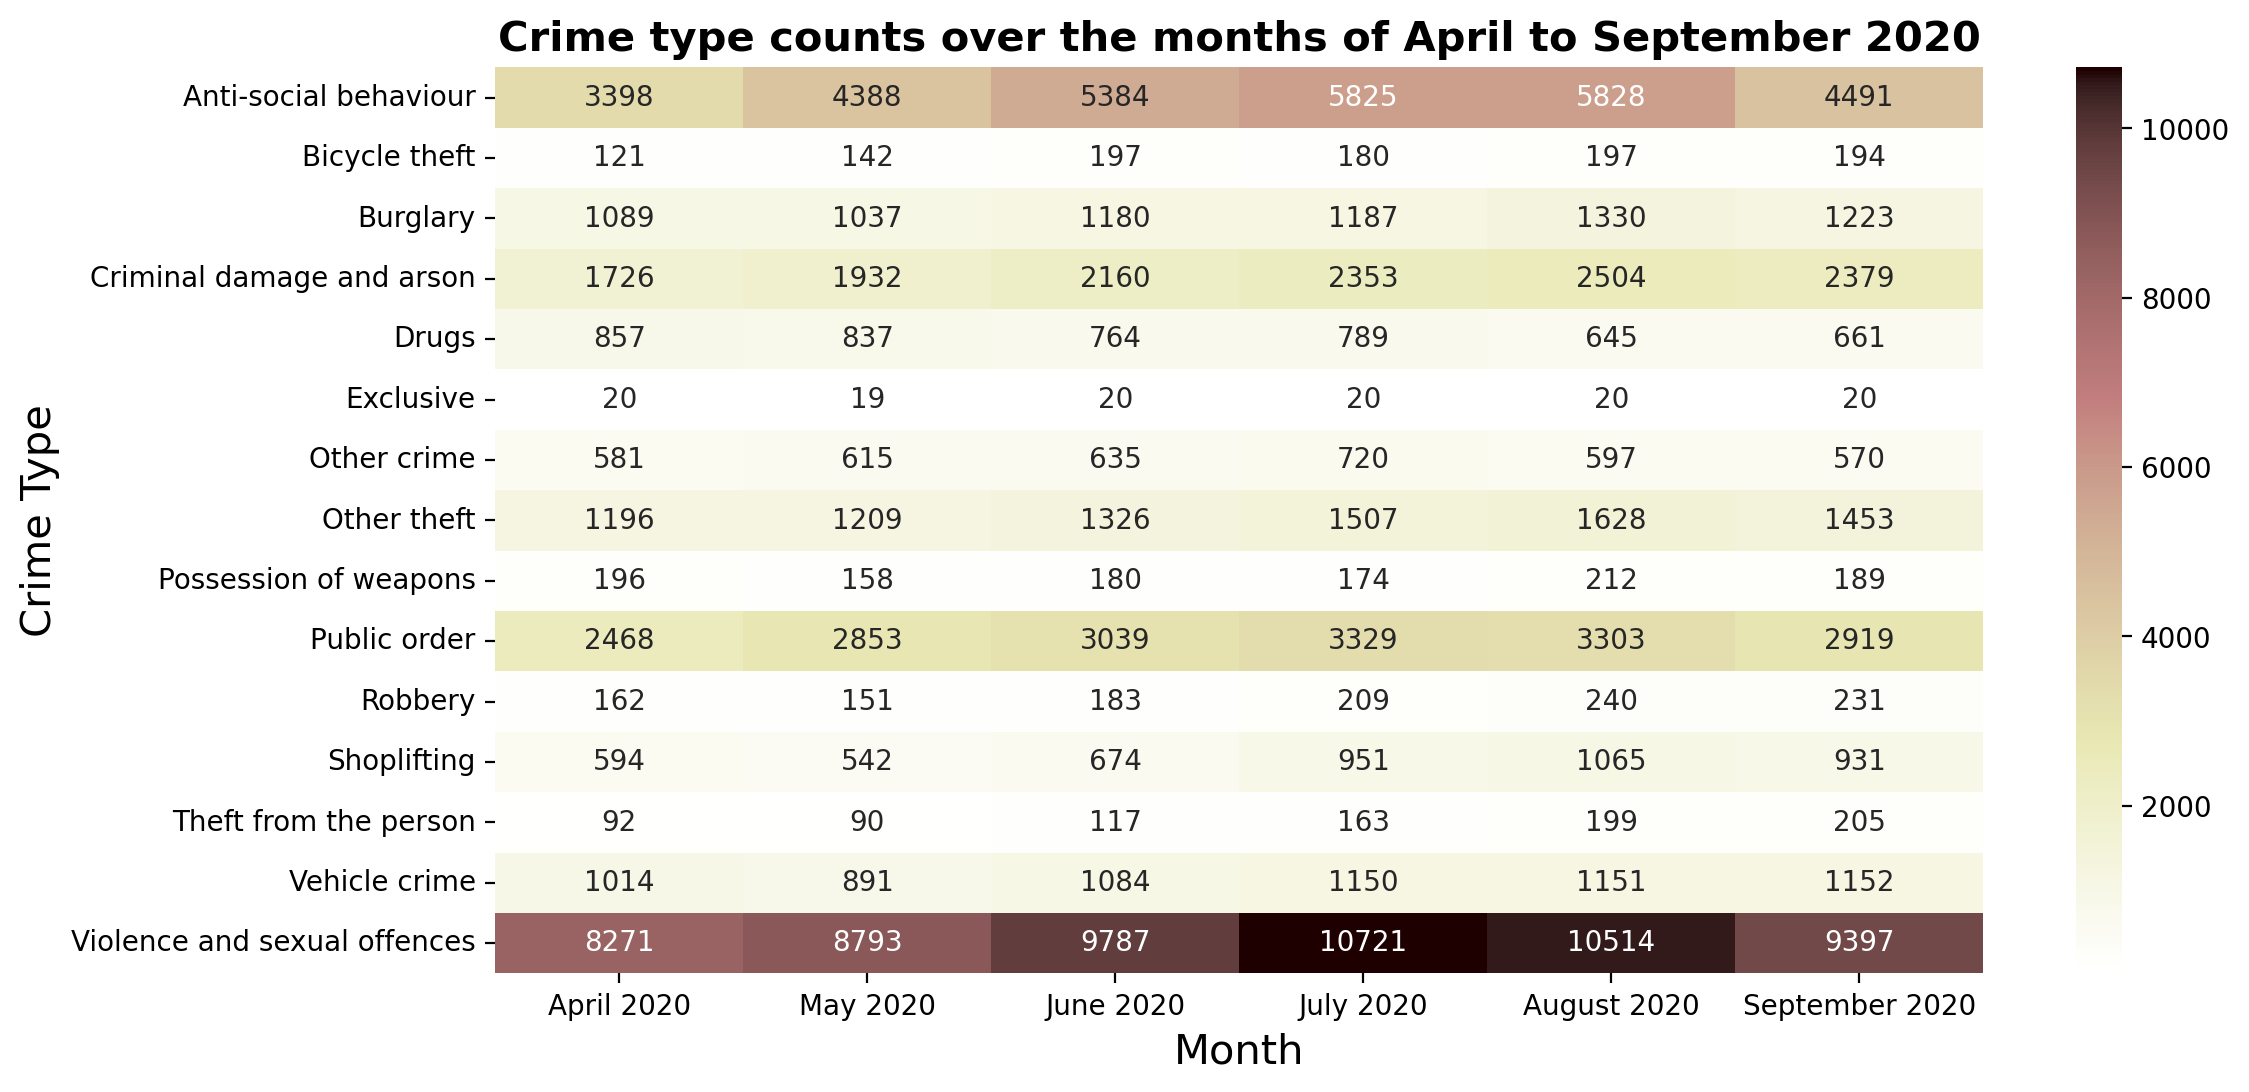

In [10]:
# Pivot the DataFrame to get counts of crime types per month
pivot_table = df.pivot_table(index='Crime type', columns='Month', aggfunc='size', fill_value=0)

# Create a heatmap plot
plt.figure(figsize=(12, 6), dpi=200)
sns.heatmap(pivot_table, cmap='pink_r', annot=True, fmt='d')

# Format X-axis labels
x_labels = pivot_table.columns.strftime("%B %Y")

# Calculate the center positions for each column
center_positions = [i + 0.5 for i in range(len(x_labels))]

# Set the tick locations at the center positions
plt.gca().set_xticks(center_positions)
plt.gca().set_xticklabels(x_labels, rotation=0)

plt.xlabel('Month', fontsize=15)
plt.ylabel('Crime Type', fontsize=15)
plt.title('Crime type counts over the months of April to September 2020', fontsize=15, fontweight='bold')
plt.show()

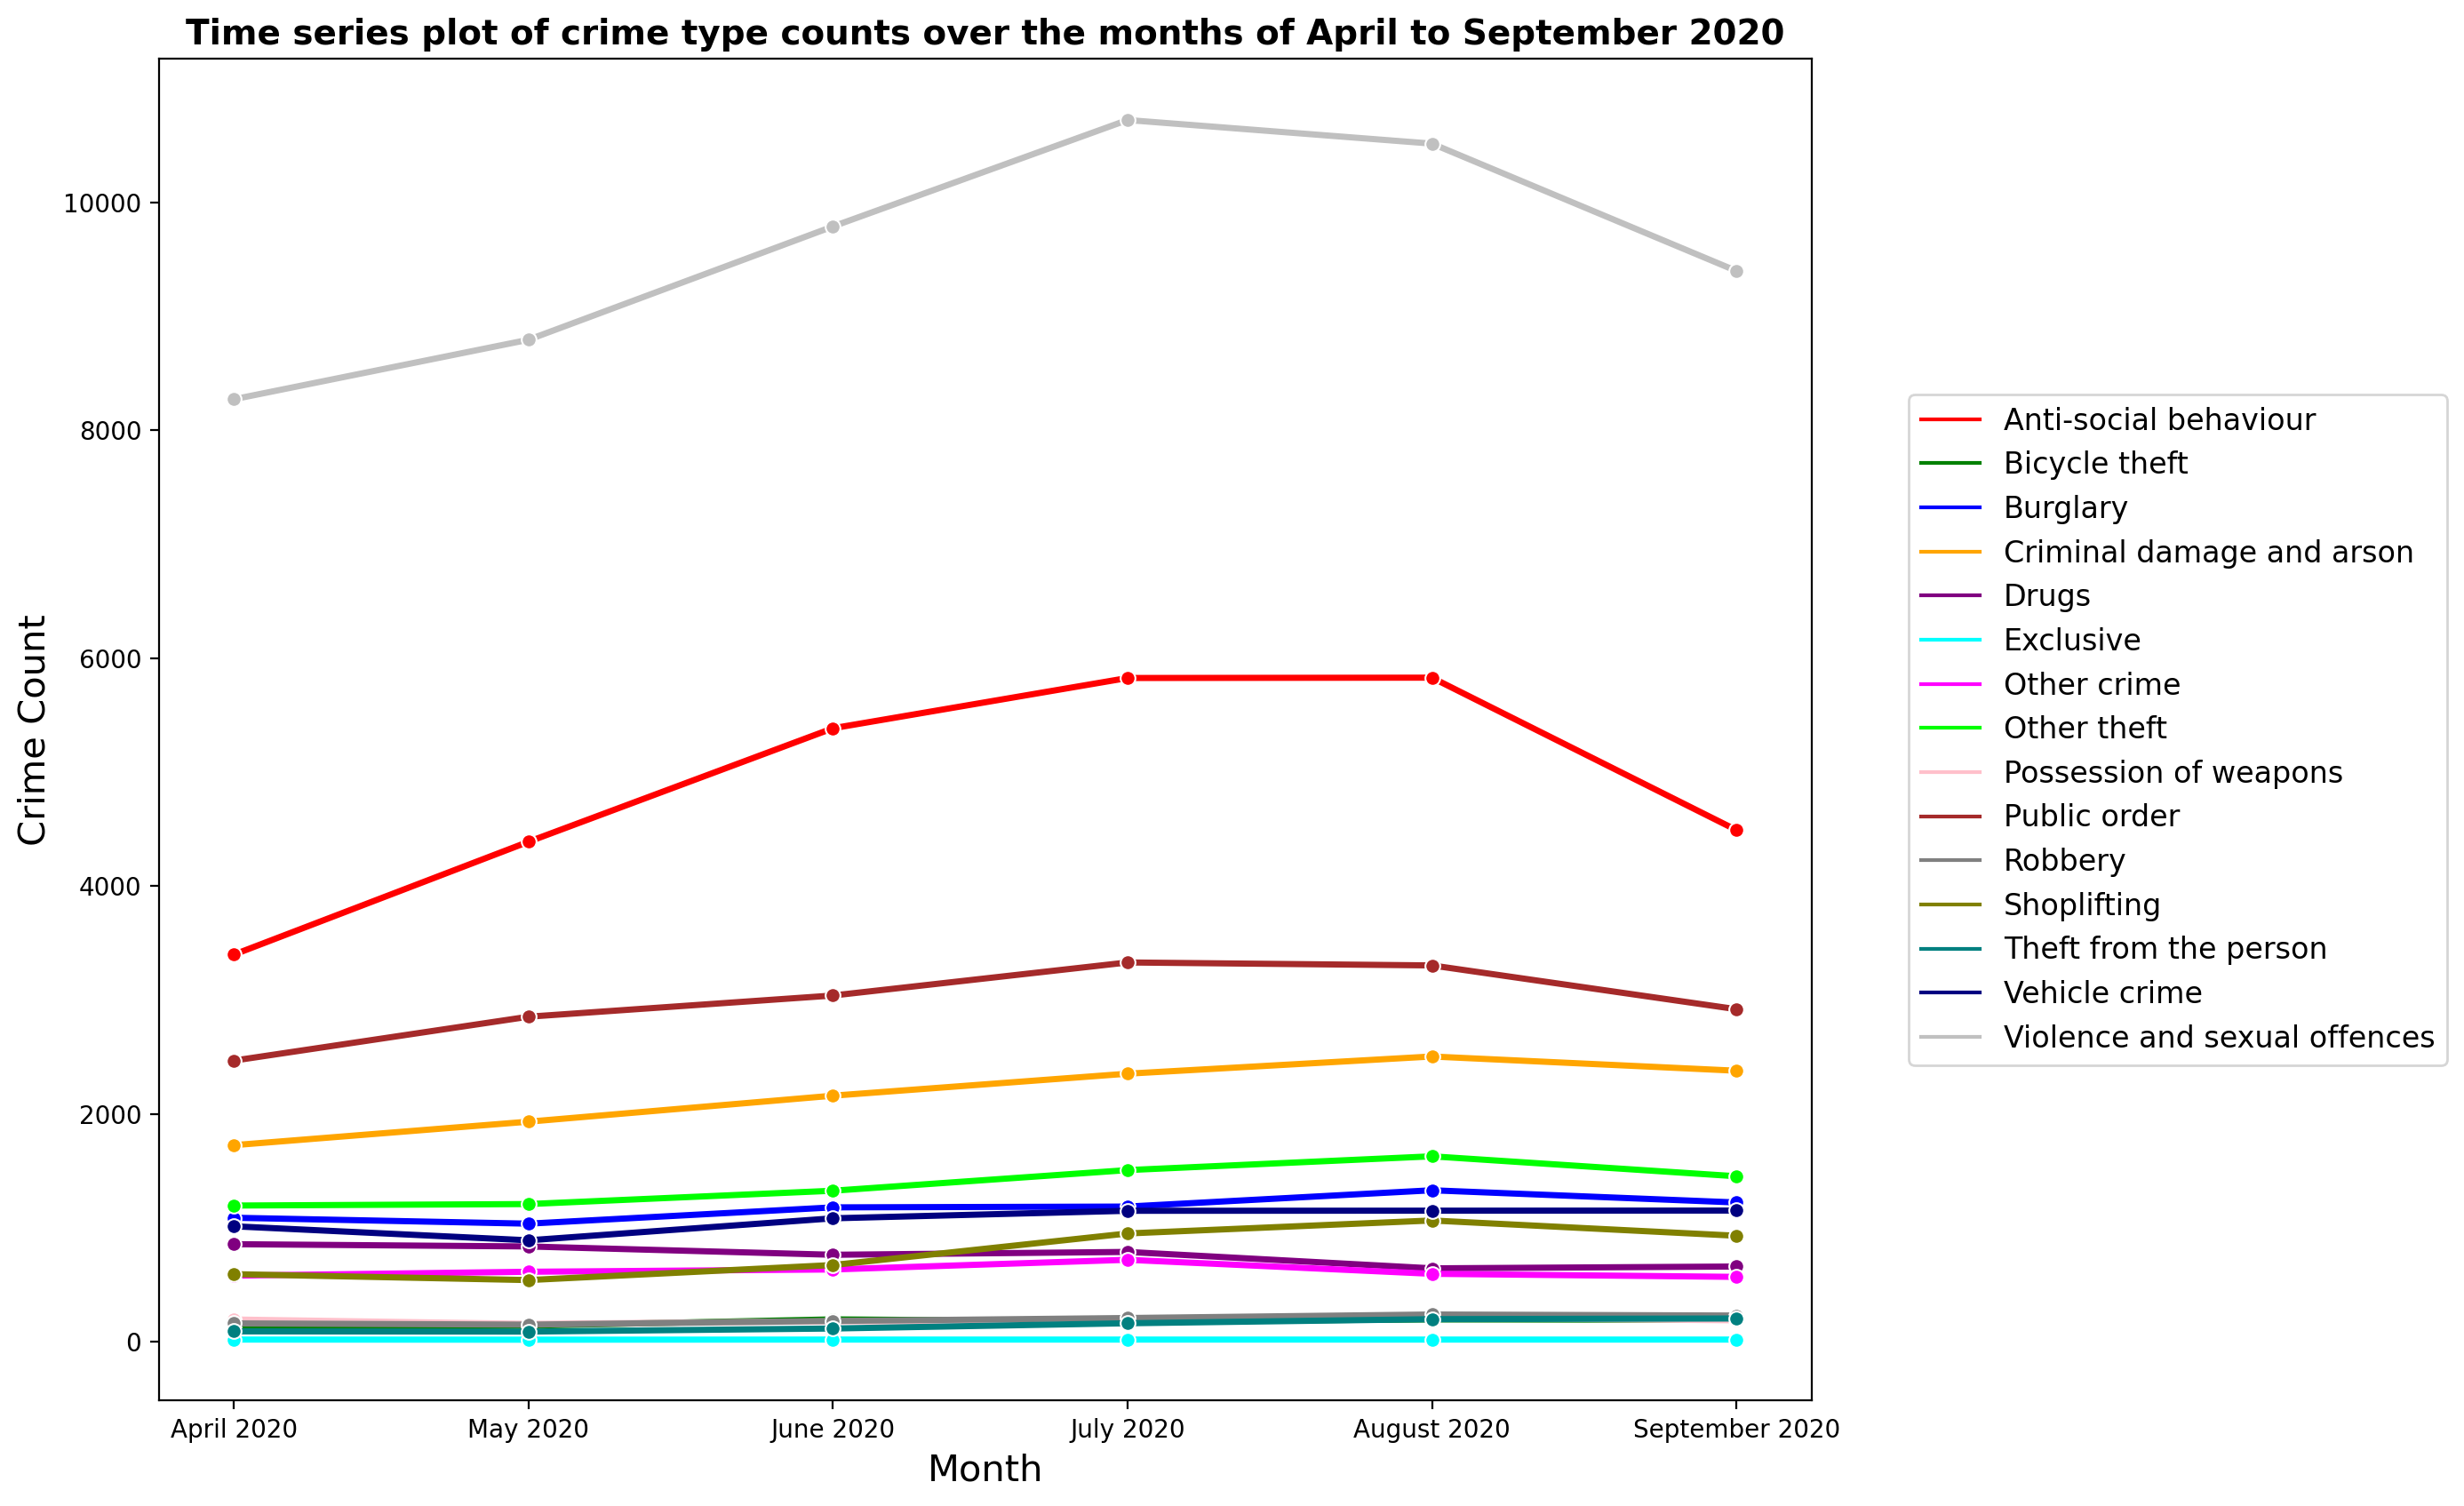

In [11]:
# Group the data by Month and Crime type and get the counts
grouped_df = df.groupby(['Month', 'Crime type'])['Crime type'].count().to_frame().rename(
    columns={'Crime type': 'Count'}).reset_index()

# Create a time-series line plot using the new grouped dataframe
# Create figure canvas
plt.figure(figsize=(12,10), dpi=200)

# Genrate a custom palette to make the legends easily distinguishable by the human eye
# If the data changes and there are more than 15 unique crime types, more colors have to be added to the color
# palette. Alternatively, larger inbuilt seaborn color palettes can be used.
custom_palette = ['red', 'green', 'blue', 'orange', 'purple', 'cyan', 'magenta',
                    'lime', 'pink', 'brown', 'gray', 'olive', 'teal', 'navy', 'silver']

# Create a seaborn lineplot and label appropriately.
sns.lineplot(data=grouped_df, y='Count', x='Month', hue='Crime type', palette=custom_palette,
            linewidth=2.5, markers=True, marker='o')

# Format x-axis labels as "Month Year" using DateFormatter
date_formatter = plt.matplotlib.dates.DateFormatter('%B %Y')
plt.gca().xaxis.set_major_formatter(date_formatter)

# Label appropriately
plt.xlabel('Month', fontsize=15)
plt.ylabel('Crime Count', fontsize=15)
plt.title('Time series plot of crime type counts over the months of April to September 2020', 
          fontsize=14, fontweight='bold')

# Optimise legend position
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', fontsize=12)

# Display figure
plt.show()

### In the time-series plot above, the trend becomes a little bit unclear for crime counts below 2000. Hence, a way to dynamically magnify crime types with lower counts would be insightful.

### The figure below shows the same plot above. However, each axis of the figure shows crime types with different count ranges.

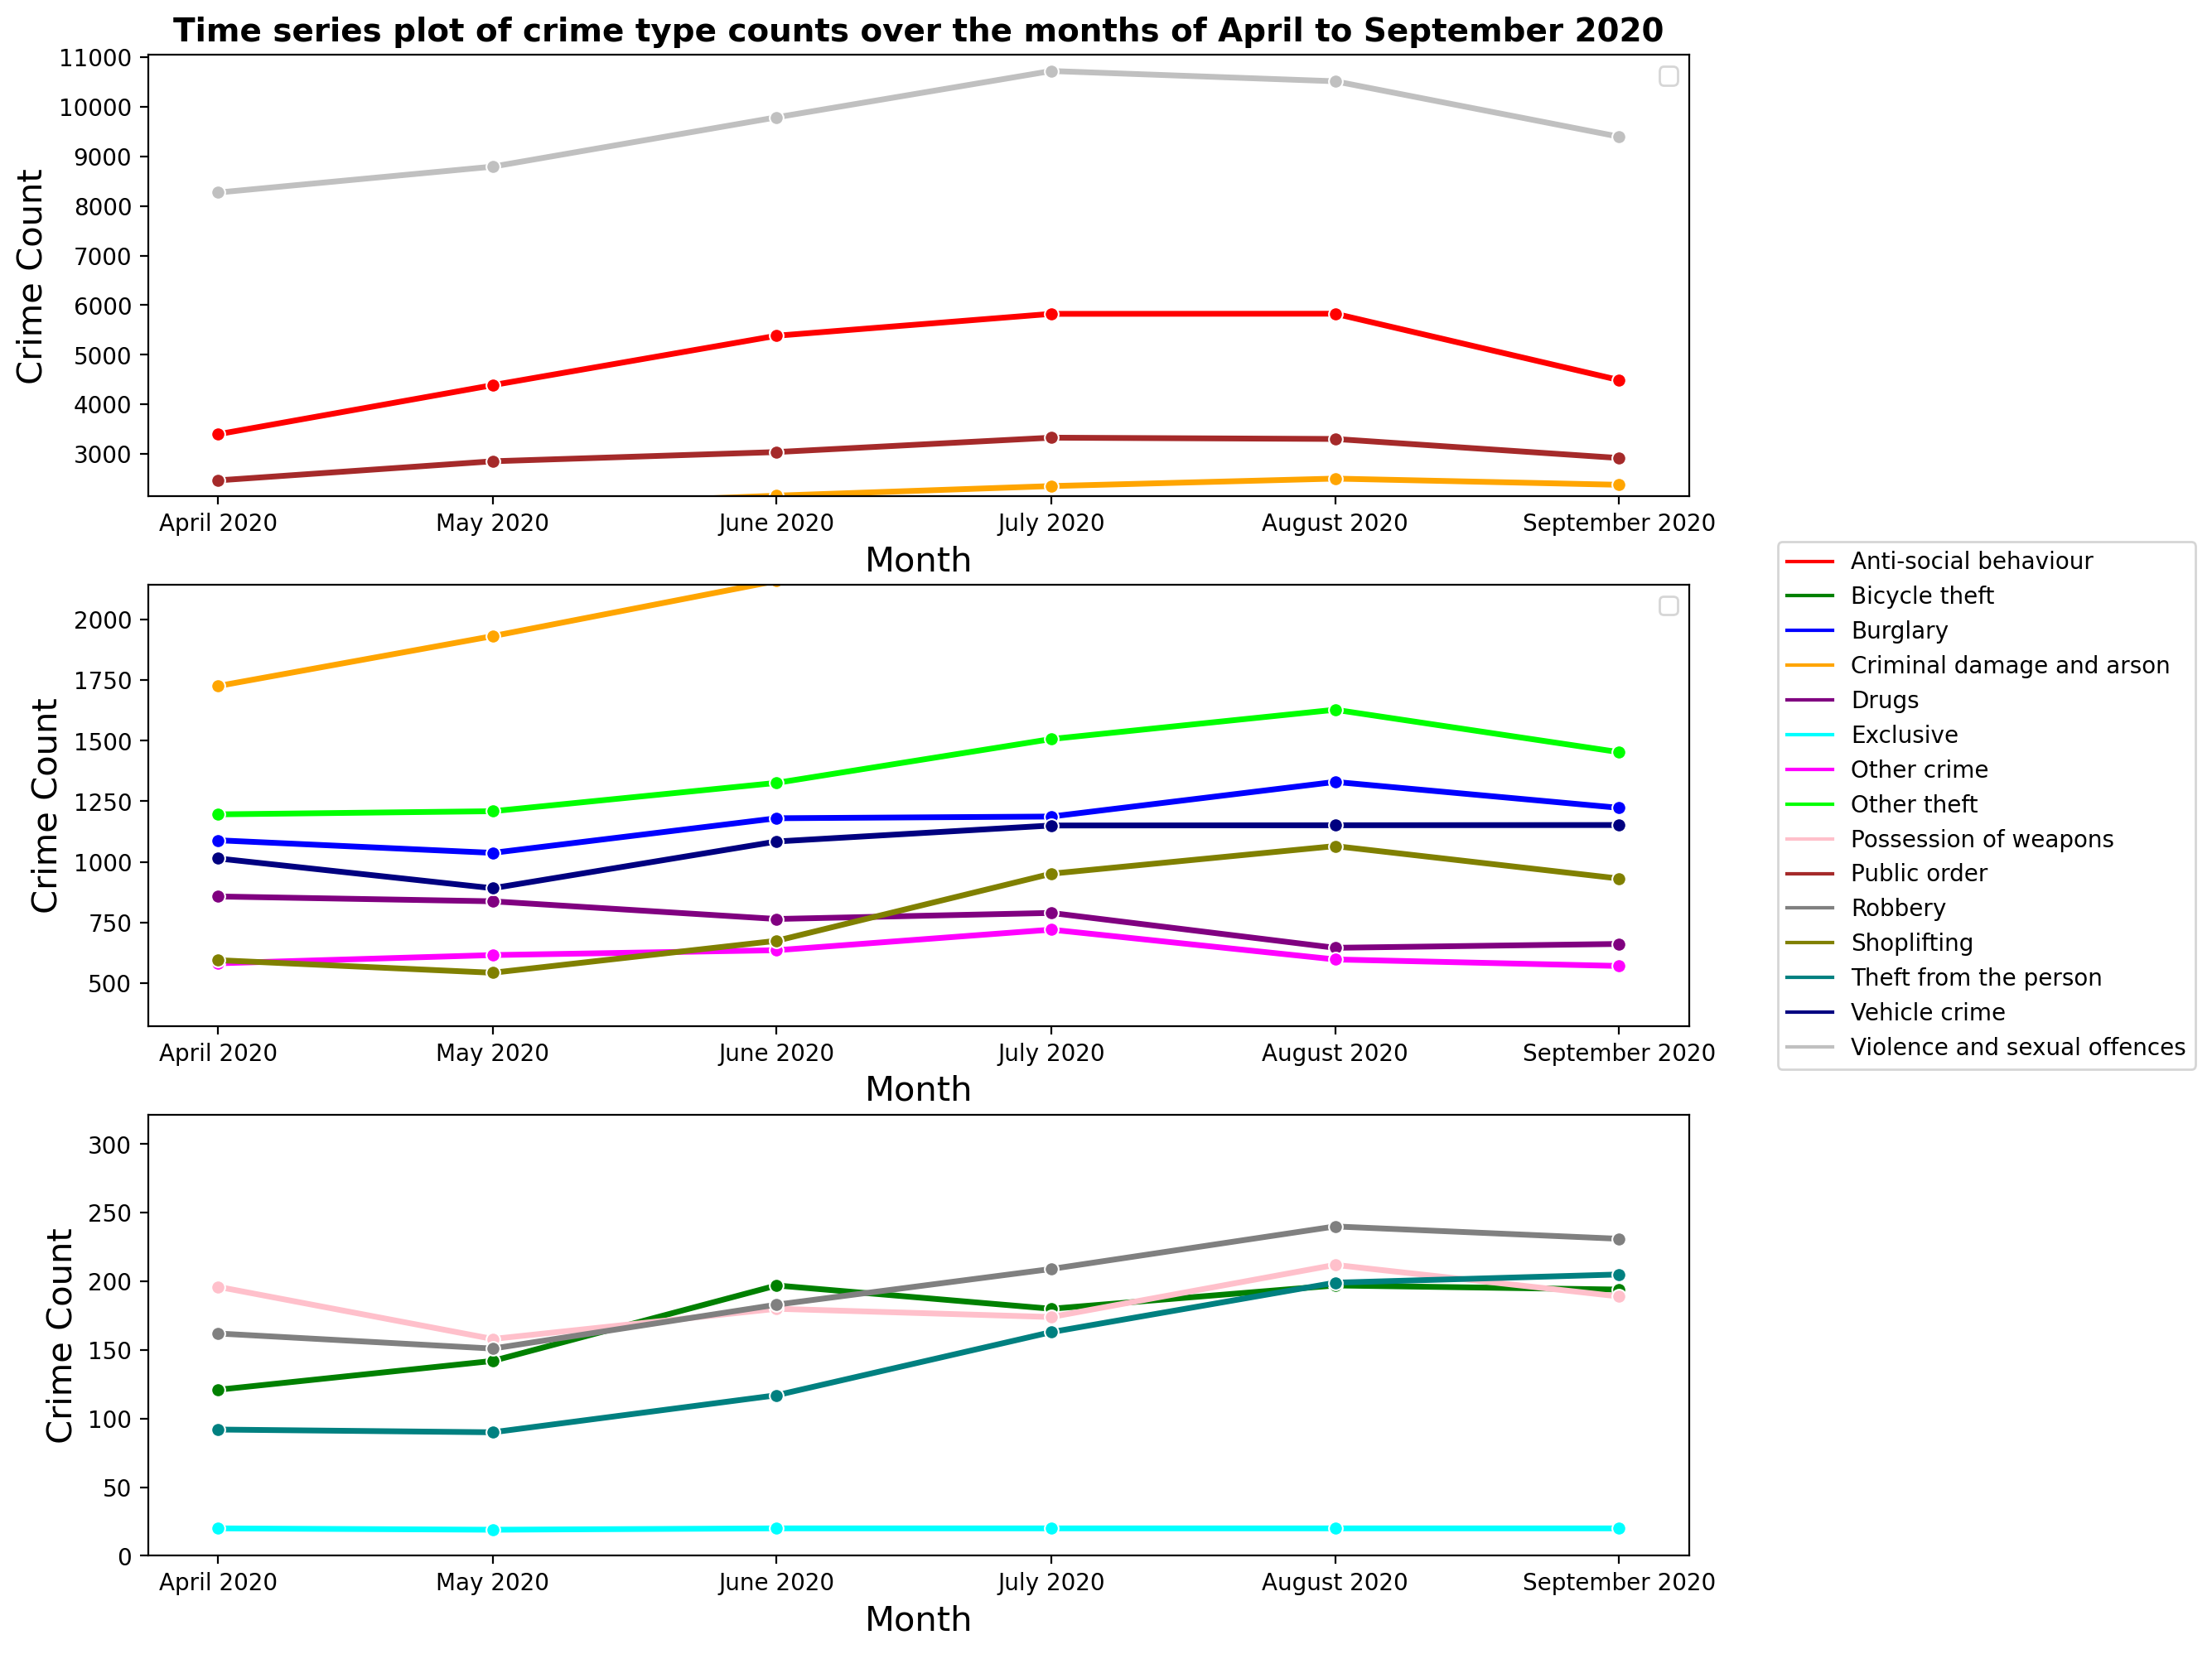

In [12]:
# Create figure canvas with three axes
fig, (ax1, ax2, ax3) = plt.subplots(nrows=3, figsize=(12,12), dpi=200)

# Define dynamic y_limits for magnification to accomodate any count if the dataset changes
# These y_limits can be custom-adjusted depending on the nature of the data.
max_count = grouped_df['Count'].max()
y_limits = [(max_count*0.2, max_count+(max_count*0.03)), 
            (max_count*0.03, max_count*0.2), 
            (0, max_count*0.03)]

# Iterate through the axes and create the necessary plots
for i, ax in enumerate([ax1, ax2, ax3]):
    sns.lineplot(data=grouped_df, y='Count', x='Month', hue='Crime type', palette=custom_palette, ax=ax,
                 linewidth=2.5, markers=True, marker='o')
    ax.set_xlabel('Month', fontsize=15)
    ax.set_ylabel('Crime Count', fontsize=15)
    ax.set_ylim(y_limits[i])
    ax.legend([])
    ax.xaxis.set_major_formatter(date_formatter)

# Position figure title above the first axis
ax1.set_title('Time series plot of crime type counts over the months of April to September 2020',
             fontsize=14, fontweight='bold')

# Optimise legend position
plt.legend(bbox_to_anchor=(1.05, 1.7), loc='center left')
plt.show()

### Generally, it seems crimes increases steadily from April to July/August and then start declining towards September. 
### However, crimes related to drugs declined throughout the 6-month period while crimes labelled exclusive neither declined nor increased.

# Conclusions

### It makes sense for crime rates to increase during the summer months (June, July, August). The warmer weather and longer days may contribute to more people being out and about, which can increase opportunities for criminal activities. The results also probably makes sense considering the first and second lockdowns in the UK in 2020. However, since there was a lockdown, should the crime count be this much?

# Additional comments
### Apart from the columns that were completely empty, the presence of null values in the 'Crime ID' casts doubt on the integrity of this dataset. Best practices require that each row should have a unique Crime ID. This will also make it easier to identify duplicates, if any. Thus, these datasets may be incomplete and consequently, these analyses may be slightly incorrect. Any analysis is only as good as the data being analysed!
### It is redundant that two columns, 'Reported by' and 'Falls within' contain the exact same information.
### With more time, it will be nice to have an interactive graphic user interface (GUI)-based dashboard that will assist with data visualization especially for the time-series plots. That way, the trend for each crime type can be selectively visualised and compared with any other desired crime type(s). Python libraries like Tkinter and PyQt would be useful here.
### Finally, with more time and data, predicting the frequency of crime occurence each month using auto-regressive models will be valuable. 
